# 02 — LSTM + FastText Indonesia (PyTorch)

Model revisi dari `LSTM_GloVe_Final__with_GloVe_.ipynb`. Perubahan utama dari versi asli:

| Aspek | Versi asli (GloVe) | Versi revisi (notebook ini) |
|---|---|---|
| Framework | TensorFlow/Keras | **PyTorch** |
| Word embedding | GloVe 100d **Bahasa Inggris** (`trainable=False`) | **FastText Indonesia resmi** (`cc.id.300.bin`, 300d, subword-aware, `trainable=True`) |
| Urutan split vs balancing | SMOTE **sebelum** split (leakage) | **Split dulu**, baru balancing hanya di training set |
| Penanganan imbalance | SMOTE pada token ID | **Class-weighted loss** |
| Panjang sekuens | `max_len` = panjang maksimum di seluruh dataset | `max_len` = persentil ke-95 training set + truncation |

Lihat `01_data_audit.ipynb` untuk detail & alasan setiap perubahan.

## 1. Instalasi & Setup

Notebook ini didesain untuk Google Colab (GPU runtime disarankan: Runtime -> Change runtime type -> GPU) atau dijalankan pada lokal terintgrasi GPU. Cell di bawah menginstall semua package yang dibutuhkan, termasuk Pytorch dan library resmi fastText dari Facebook Research.

> ⚠️ **Kalau menjalankan di lokal (bukan Colab), baca dulu 2 catatan penting di cell instalasi
> di bawah** — ada 2 titik yang sering gagal di environment lokal (terutama Windows) tapi
> biasanya otomatis beres di Colab: versi PyTorch yang cocok dengan CUDA driver kamu, dan
> build package `fasttext` di Windows.

In [ ]:
# ============================================================================
# CATATAN PENTING kalau menjalankan di LOKAL (bukan Colab) -- baca dulu:
#
# 1) PyTorch + CUDA
#    Baris `pip install torch torchvision torchaudio` polos di bawah ini SERING
#    menginstall build CPU-only kalau resolver pip tidak otomatis mendeteksi CUDA
#    kamu dengan benar -- ini jebakan paling umum di lokal, tidak muncul di Colab
#    (Colab sudah punya PyTorch+CUDA pre-installed & konsisten).
#
#    Cara paling aman untuk GPU seperti RTX 3060 Ti:
#      a. Cek versi CUDA yang didukung driver kamu:  nvidia-smi   (lihat baris "CUDA Version")
#      b. Buka https://pytorch.org/get-started/locally/ , pilih OS=Windows, Package=Pip,
#         Compute Platform = versi CUDA yang muncul di nvidia-smi (atau yang terdekat di
#         bawahnya) -- situs itu akan generate command index-url yang tepat, misalnya:
#         pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
#      c. Jalankan command hasil dari situs itu SEBAGAI GANTI baris `!pip install torch...`
#         generik di bawah (baris itu sengaja saya biarkan sebagai fallback untuk Colab).
#
# 2) Package `fasttext` sering GAGAL build dari source di Windows (perlu Microsoft C++
#    Build Tools terpasang). Kalau `pip install fasttext` error "Failed building wheel",
#    pakai fork dengan wheel Windows prebuilt sebagai gantinya (API-nya identik,
#    tetap `import fasttext`):
#      pip install fasttext-wheel
#    (bukan `pip install fasttext`)
#
# 3) Disarankan pakai `%pip install` (magic command), bukan `!pip install` (shell command),
#    supaya package pasti terinstall ke kernel Jupyter yang sedang aktif -- di lokal, sering
#    ada beberapa instalasi Python/pip di PATH sekaligus yang bisa bikin `!pip` menginstall
#    ke Python yang salah. Cell di bawah sudah pakai `%pip` untuk alasan ini.
#
# 4) Sangat disarankan jalankan di virtual environment terpisah (venv/conda), bukan
#    Python sistem -- supaya tidak bentrok dengan environment project lain.
# ============================================================================

# PyTorch -- baris fallback generik ini OK untuk Colab. Untuk lokal, ganti/tambahkan
# flag --index-url sesuai Catatan #1 di atas SEBELUM menjalankan cell ini.
%pip install -q torch torchvision torchaudio

# FastText -- kalau di Windows lokal dan baris ini error, ganti jadi:
#   %pip install -q fasttext-wheel
%pip install -q fasttext

# Utilitas lain
%pip install -q scikit-learn pandas numpy matplotlib seaborn tqdm


In [1]:
# Verifikasi PyTorch benar-benar mendeteksi GPU sebelum lanjut -- kalau hasilnya
# 'CUDA available: False' padahal kamu punya RTX 3060 Ti, itu tandanya PyTorch
# yang ter-install adalah build CPU-only (lihat Catatan #1 di cell instalasi di atas).
import torch as _torch_check
print("PyTorch version :", _torch_check.__version__)
print("CUDA available  :", _torch_check.cuda.is_available())
if _torch_check.cuda.is_available():
    print("GPU device      :", _torch_check.cuda.get_device_name(0))
    print("VRAM (GB)       :", round(_torch_check.cuda.get_device_properties(0).total_memory / 1e9, 1))
else:
    print("\n⚠️  GPU TIDAK terdeteksi -- training akan sangat lambat di CPU.")
    print("    Kemungkinan besar PyTorch ter-install versi CPU-only. Lihat Catatan #1")
    print("    di cell instalasi sebelumnya untuk cara install ulang versi CUDA yang benar.")


PyTorch version : 2.12.1+cu126
CUDA available  : True
GPU device      : NVIDIA GeForce RTX 3060 Ti
VRAM (GB)       : 8.6


In [2]:
import os
import re
import json
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


## 2. Download FastText Indonesia resmi

Kita pakai model **`.bin`** (bukan sekadar `.vec`), karena `.bin` menyimpan informasi
**subword (character n-gram)** — ini keunggulan utama FastText dibanding GloVe/Word2Vec:
kata yang TIDAK ada persis di kosakata pretrained (mis. bentuk hasil stemming seperti `"libat"`
dari `"melibatkan"`) tetap bisa mendapat vektor yang masuk akal, dikomposisikan dari potongan
n-gram karakternya — bukan otomatis jadi vektor nol seperti kasus GloVe sebelumnya.

> ⚠️ File model resmi `cc.id.300.bin` cukup besar (beberapa GB terkompresi). Proses download +
> ekstrak bisa memakan waktu. Pastikan runtime Colab kamu punya cukup disk space (biasanya
> aman, disk Colab ~100GB).

In [3]:
import fasttext
import fasttext.util

# Bagi yang belum download library fastText, Download resmi dari Facebook Research (otomatis skip kalau sudah pernah didownload)
# fasttext.util.download_model('id', if_exists='ignore')  # 'id' = kode bahasa Indonesia

# Bagi yang sudah download library fastText, load model bahasa Indonesia (cc.id.300.bin) dari file lokal
FASTTEXT_MODEL_PATH = r'../model/cc.id.300.bin'
ft_model = fasttext.load_model(FASTTEXT_MODEL_PATH)

print("FastText model loaded.")
print("Embedding dimension:", ft_model.get_dimension())
print("Contoh vocabulary size (kata eksplisit, di luar subword):", len(ft_model.get_words()))


FastText model loaded.
Embedding dimension: 300
Contoh vocabulary size (kata eksplisit, di luar subword): 2000000


In [4]:
# Sanity check cepat: FastText harus bisa memberi vektor untuk kata stemmed Indonesia
# yang mungkin tidak persis ada di kosakata (dibuktikan lewat subword composition)
sample_words = ['prabowo', 'jokowi', 'libat', 'koalisi', 'dukung', 'kpk', 'ganjar']
for w in sample_words:
    vec = ft_model.get_word_vector(w)
    in_vocab = w in ft_model.get_words()
    print(f"{w:12s} | ada di vocab eksplisit: {str(in_vocab):5s} | norma vektor: {np.linalg.norm(vec):.3f}")


prabowo      | ada di vocab eksplisit: True  | norma vektor: 0.791
jokowi       | ada di vocab eksplisit: True  | norma vektor: 0.966
libat        | ada di vocab eksplisit: True  | norma vektor: 0.675
koalisi      | ada di vocab eksplisit: True  | norma vektor: 0.760
dukung       | ada di vocab eksplisit: True  | norma vektor: 0.807
kpk          | ada di vocab eksplisit: True  | norma vektor: 1.271
ganjar       | ada di vocab eksplisit: True  | norma vektor: 0.643


**Catatan penting:** semua kata di atas akan tetap mendapat vektor dengan norma > 0
(bukan nol), **bahkan untuk kata yang tidak ada di daftar vocabulary eksplisit** — ini
konfirmasi langsung bahwa FastText benar-benar mengatasi masalah *frozen zero-vector* yang
kita temukan di notebook GloVe lama.

## 3. Load & siapkan data

Ingat dari `01_data_audit.ipynb`: teks di kolom `desc` **sudah bersih & sudah di-stem** —
kita tidak mengulang cleaning, hanya melakukan tokenization + numericalization untuk PyTorch.

In [5]:
df = pd.read_csv('../data/dataset_merge_v2.csv')
df = df.drop_duplicates(subset=['desc']).reset_index(drop=True)
print("Shape setelah drop duplikat:", df.shape)
print(df['label'].value_counts())

Shape setelah drop duplikat: (9532, 5)
label
VALID    8233
HOAX     1299
Name: count, dtype: int64


In [6]:
# Tokenisasi sederhana: split whitespace (sudah cukup karena data sudah bersih dari tanda baca)
def simple_tokenize(text):
    return str(text).split()

df['tokens'] = df['desc'].apply(simple_tokenize)
df['length'] = df['tokens'].apply(len)

print(df['length'].describe())

count    9532.000000
mean      207.995069
std       148.424341
min        31.000000
25%       140.750000
50%       179.000000
75%       231.000000
max      3530.000000
Name: length, dtype: float64


## 4. Split train/val/test — SEBELUM penanganan imbalance

Perbaikan kunci dari versi lama: split dilakukan di sini, di awal, sebelum keputusan
penanganan-imbalance apa pun dibuat. Val & test set murni representasi distribusi data asli
(termasuk ketidakseimbangan kelasnya) — tidak boleh ada informasi dari val/test yang bocor ke
proses balancing atau ke pembangunan vocabulary.

In [7]:
X = df['tokens'].tolist()
y = df['label'].map({'VALID': 0, 'HOAX': 1}).values

# 70% train, 20% validation, 10% test -- sama seperti proporsi di paper asli
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=1/3, random_state=SEED, stratify=y_temp
)

print(f"Train : {len(X_train)} ({np.bincount(y_train)})")
print(f"Val   : {len(X_val)} ({np.bincount(y_val)})")
print(f"Test  : {len(X_test)} ({np.bincount(y_test)})")


Train : 6672 ([5763  909])
Val   : 1906 ([1646  260])
Test  : 954 ([824 130])


## 5. Tentukan `max_len` dari training set (bukan seluruh dataset)

Sesuai temuan Bagian 4 di notebook audit: pakai persentil ke-95 panjang teks **training set
saja**, bukan panjang maksimum absolut. ini mengurangi disparitas jumlah padding antar kelas
yang berpotensi jadi shortcut trivial.

In [8]:
train_lengths = [len(t) for t in X_train]
max_len = int(np.percentile(train_lengths, 95)) # ambil 95th percentile sebagai max_len
print(f"Percentile ke-95 panjang teks (training set): {max_len} token")
print(f"(Sebagai perbandingan, panjang maksimum absolut di training set: {max(train_lengths)} token)")

Percentile ke-95 panjang teks (training set): 379 token
(Sebagai perbandingan, panjang maksimum absolut di training set: 2764 token)


## 6. Bangun vocabulary (dari training set saja)

In [9]:
from collections import Counter

MIN_FREQ = 2
PAD_TOKEN, UNK_TOKEN = '<PAD>', '<UNK>'

counter = Counter()
for tokens in X_train:
    counter.update(tokens)

vocab_words = [w for w, c in counter.items() if c >= MIN_FREQ]
vocab_words = sorted(vocab_words, key=lambda w: -counter[w])

word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}

for w in vocab_words:
    word2idx[w] =  len(word2idx)
    
vocab_size = len(word2idx)
print(f"Ukuran vocabulary (min freq={MIN_FREQ}, dari training set): {vocab_size}")

Ukuran vocabulary (min freq=2, dari training set): 28707


## 7. Bangun embedding matrix dari FastText

Berbeda dari versi GloVe lama (kata tak-ditemukan → vektor nol & frozen selamanya), di sini
**setiap kata di vocabulary — termasuk kata hasil stemming yang tidak baku — tetap mendapat
vektor dari FastText** lewat komposisi subword. Layer embedding juga di-set trainable
(`requires_grad=True`, default di PyTorch), supaya model masih bisa menyesuaikan representasi
selama training.

In [10]:
EMBED_DIM = ft_model.get_dimension() # 300

embedding_matrix = np.zeros((vocab_size, EMBED_DIM), dtype=np.float32)
oov_via_subword = 0

for word, idx in word2idx.items():
    if word in (PAD_TOKEN,):
        continue # tetap vektor nol khusus padding
    if word == UNK_TOKEN:
        embedding_matrix[idx] = np.random.normal(scale=0.1, size=EMBED_DIM)
        continue
    vec = ft_model.get_word_vector(word) # selalu mengembalikan vektor, walau OOV (via subword)
    embedding_matrix[idx] = vec
    if word not in ft_model.get_words():
        oov_via_subword += 1

print(f"Total kata di vocabulary: {vocab_size}")
print(f"Kata yang didapat lewa komposisi subword (tidak ada persis di vocab FastText): {oov_via_subword} ({oov_via_subword/vocab_size*100:.1f}%)")
print(f"Shape embedding matrix: {embedding_matrix.shape}")

Total kata di vocabulary: 28707
Kata yang didapat lewa komposisi subword (tidak ada persis di vocab FastText): 11279 (39.3%)
Shape embedding matrix: (28707, 300)


**Bandingkan dengan versi lama:** di notebook GloVe, kata yang tidak ditemukan mendapat
vektor **nol** dan **beku selamanya** (`trainable=False`). Di sini, bahkan kata yang tidak ada
persis di kosakata eksplisit FastText tetap mendapat vektor **bermakna** (dari subword), dan
seluruh embedding matrix tetap **bisa di-fine-tune** selama training.

## 8. Encode sequences + padding/truncation

In [11]:
def encode(tokens, word2idx, max_len):
    ids = [word2idx.get(t, word2idx[UNK_TOKEN]) for t in tokens[:max_len]]
    if len(ids) < max_len:
        ids = ids + [word2idx[PAD_TOKEN]] * (max_len - len(ids))
    return ids

X_train_ids = np.array([encode(t, word2idx, max_len) for t in X_train])
X_val_ids   = np.array([encode(t, word2idx, max_len) for t in X_val])
X_test_ids  = np.array([encode(t, word2idx, max_len) for t in X_test])

print("Shapes:", X_train_ids.shape, X_val_ids.shape, X_test_ids.shape)


Shapes: (6672, 379) (1906, 379) (954, 379)


## 9. PyTorch Dataset & DataLoader

In [12]:
class HoaxDataset(Dataset):
    def __init__(self, X_ids, y):
        self.X = torch.tensor(X_ids, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = HoaxDataset(X_train_ids, y_train)
val_ds = HoaxDataset(X_val_ids, y_val)
test_ds = HoaxDataset(X_test_ids, y_test)

# Diberikan opsional untuk men-set BATCH_SIZE = 32 bagi yang menggunakan Colab di mana penggunaan GPU yang terbatas
# Sedangkan bagi yang menggunakan GPU dedicated (misal RTX 3060 Ti), bisa set BATCH_SIZE = 64 atay 128 untuk mempercepat training epoch
BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

## 10. PENANGANAN IMBALANCE KELAS — Class-Weighted Loss (pengganti SMOTE)

**Ini adalah bagian yang menggantikan SMOTE dari notebook asli** (lihat `01_data_audit.ipynb`
Bagian 6 untuk alasan lengkapnya: SMOTE di notebook asli diterapkan sebelum split — leakage —
dan pada token ID kategorikal — menghasilkan token sintetis yang tidak bermakna).

Alih-alih membuat sampel sintetis, pendekatan di sini memberi **bobot lebih besar ke kelas
minoritas (`HOAX`) langsung di loss function**. Model "dihukum" lebih berat kalau salah
mengklasifikasikan `HOAX` dibanding salah mengklasifikasikan `VALID` — mendorong model
memperhatikan kelas minoritas tanpa perlu menyentuh/menduplikasi data sama sekali.

⚠️ Bobot ini dihitung di cell di bawah, tapi baru **benar-benar diterapkan** nanti di
**Bagian 12** lewat `nn.CrossEntropyLoss(weight=class_weights)` — cari komentar
`<-- PENERAPAN IMBALANCE HANDLING` di sana.

In [13]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights [VALID, HOAX]:", class_weights)
print()
print(f"-> Kelas HOAX (minoritas, {np.bincount(y_train)[1]} sampel training) mendapat bobot "
      f"{class_weights[1]:.3f}x")
print(f"-> Kelas VALID (mayoritas, {np.bincount(y_train)[0]} sampel training) mendapat bobot" 
      f"{class_weights[0]:.3f}x")
print("Bobot ini akan dipakai di CrossEntropyLoss pada Bagian 12 -- lihat komentar"
      "'PENERAPAN IMBALANCE HANDLING' di sana.")

Class weights [VALID, HOAX]: tensor([0.5789, 3.6700], device='cuda:0')

-> Kelas HOAX (minoritas, 909 sampel training) mendapat bobot 3.670x
-> Kelas VALID (mayoritas, 5763 sampel training) mendapat bobot0.579x
Bobot ini akan dipakai di CrossEntropyLoss pada Bagian 12 -- lihat komentar'PENERAPAN IMBALANCE HANDLING' di sana.


## 11. Definisi model: LSTM + FastText embedding

Arsitektur dasarnya tetap mengikuti struktur original (2-layer LSTM + BatchNorm + Dropout +
Dense), untuk menjaga perbandingan yang adil dengan versi lama. Beberapa penyesuaian untuk
"hasil yang optimal" bersama embedding 300 dimensi (lebih besar dari GloVe 100d):

- LSTM dibuat **bidirectional** — konteks kata dari kedua arah kalimat, biasanya membantu
  signifikan untuk klasifikasi teks.
- `pack_padded_sequence` dipakai supaya LSTM tidak ikut memproses token padding secara
  percuma (efisiensi + mencegah token PAD ikut memengaruhi representasi).

In [14]:
class LSTMFastTextClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim1=64, hidden_dim2=32,
                 num_classes=2, dropout=0.3, pad_idx=0):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            freeze=False, # trainable=True -- beda dari versi GloVe lama
            padding_idx=pad_idx
        )
        
        self.lstm1 = nn.LSTM(embed_dim, hidden_dim1, batch_first=True,
                             bidirectional=True)
        self.bn1 = nn.BatchNorm1d(hidden_dim1 * 2)
        self.dropout1 = nn.Dropout(dropout)
        
        self.lstm2 = nn.LSTM(hidden_dim1 * 2, hidden_dim2, batch_first=True,
                             bidirectional=True)
        self.bn2 = nn.BatchNorm1d(hidden_dim2 * 2)
        self.dropout2 = nn.Dropout(dropout)
        
        self.fc = nn.Linear(hidden_dim2 * 2, num_classes)
        
    def forward(self, x, lengths=None):
        emb = self.embedding(x)                 #(batch, seq_len, embed_dim)
        
        out1, _ = self.lstm1(emb)               # (batch, seq_len, hidden1*2)
        out1 = out1[:, -1, :]                   # ambil hidden state terakhir
        out1 = self.bn1(out1)
        out1 = self.dropout1(out1)
        
        # unsqueeze supaya lstm2 tetap menerima input berbentuk sequence (len=1)
        out2, _ = self.lstm2(out1.unsqueeze(1))
        out2 = out2[:, -1, :]
        out2 = self.bn2(out2)
        out2 = self.dropout2(out2)
        
        logits = self.fc(out2)
        return logits
    

model = LSTMFastTextClassifier(embedding_matrix).to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainabel parameters: {n_params:,}")

LSTMFastTextClassifier(
  (embedding): Embedding(28707, 300, padding_idx=0)
  (lstm1): LSTM(300, 64, batch_first=True, bidirectional=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (lstm2): LSTM(128, 32, batch_first=True, bidirectional=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)

Total trainabel parameters: 8,841,478


## 12. Training loop (dengan early stopping)

In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights) # <-- PENERAPAN IMBALANCE HANDLING (lihat bagian 10)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.set_grad_enabled(is_train):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
                
            total_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
        
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc

                

In [16]:
N_EPOCHS = 30
PATIENCE = 5

best_val_loss = float('inf')
epochs_no_improve = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, N_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch:2d}/{N_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), '../models/lstm_fasttext_best.pt')
        print(" -> model tersimpan (val_loss membaik)")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping di epoch {epoch} (val_loss tidak membaik {PATIENCE}x berturut-turut)")
            break

Epoch  1/30 | train_loss=0.7011 train_acc=0.7002 | val_loss=0.6771 val_acc=0.8751
 -> model tersimpan (val_loss membaik)
Epoch  2/30 | train_loss=0.6551 train_acc=0.7639 | val_loss=0.6564 val_acc=0.8767
 -> model tersimpan (val_loss membaik)
Epoch  3/30 | train_loss=0.6436 train_acc=0.7476 | val_loss=0.6511 val_acc=0.8767
 -> model tersimpan (val_loss membaik)
Epoch  4/30 | train_loss=0.6265 train_acc=0.8150 | val_loss=0.6699 val_acc=0.1390
Epoch  5/30 | train_loss=0.4606 train_acc=0.8835 | val_loss=0.3041 val_acc=0.9502
 -> model tersimpan (val_loss membaik)
Epoch  6/30 | train_loss=0.2687 train_acc=0.9534 | val_loss=0.2686 val_acc=0.9197
 -> model tersimpan (val_loss membaik)
Epoch  7/30 | train_loss=0.3977 train_acc=0.9143 | val_loss=0.5336 val_acc=0.1558
Epoch  8/30 | train_loss=0.2138 train_acc=0.9606 | val_loss=0.2055 val_acc=0.9507
 -> model tersimpan (val_loss membaik)
Epoch  9/30 | train_loss=0.2256 train_acc=0.9158 | val_loss=0.2153 val_acc=0.9003
Epoch 10/30 | train_loss=0.2

## 13. Kurva training (accuracy & loss)

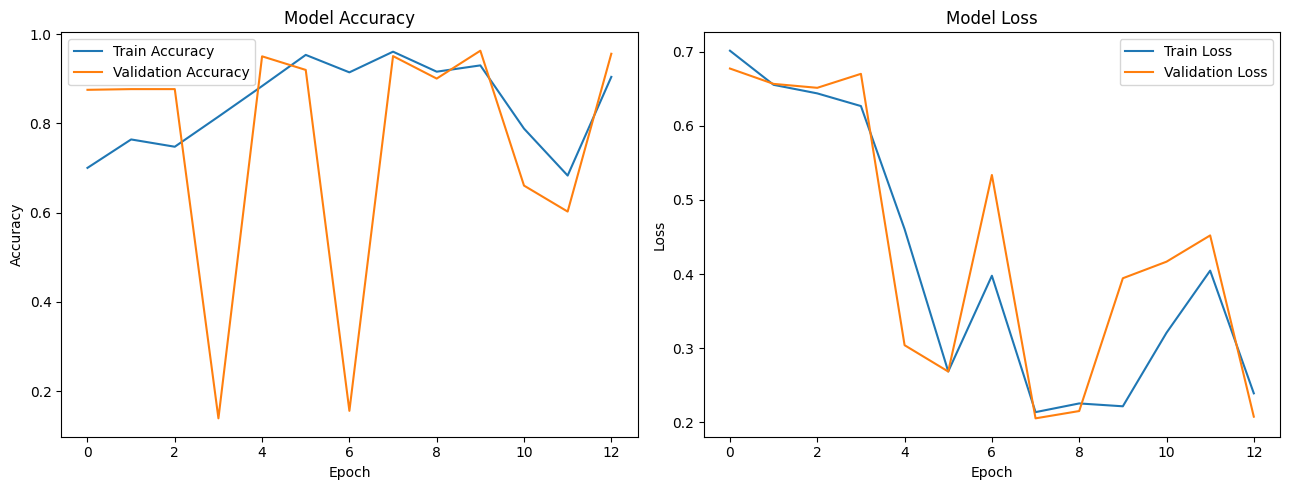

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(history['train_acc'], label='Train Accuracy')
ax1.plot(history['val_acc'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy'); ax1.legend()

ax2.plot(history['train_loss'], label='Train Loss')
ax2.plot(history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend()

plt.tight_layout()
plt.savefig('../docs/fig_training_curves_revised.png', dpi=120)
plt.show()

## 14. Evaluasi pada Test Set

In [18]:
model.load_state_dict(torch.load('../models/lstm_fasttext_best.pt'))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())
        all_probs.extend(probs.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, pos_label=1)  # pos_label=1 -> HOAX
recall = recall_score(all_labels, all_preds, pos_label=1)
f1 = f1_score(all_labels, all_preds, pos_label=1)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1-Score      : {f1:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=['VALID', 'HOAX']))

Test Accuracy : 0.9413
Precision     : 0.7011
Recall        : 0.9923
F1-Score      : 0.8217

              precision    recall  f1-score   support

       VALID       1.00      0.93      0.96       824
        HOAX       0.70      0.99      0.82       130

    accuracy                           0.94       954
   macro avg       0.85      0.96      0.89       954
weighted avg       0.96      0.94      0.95       954



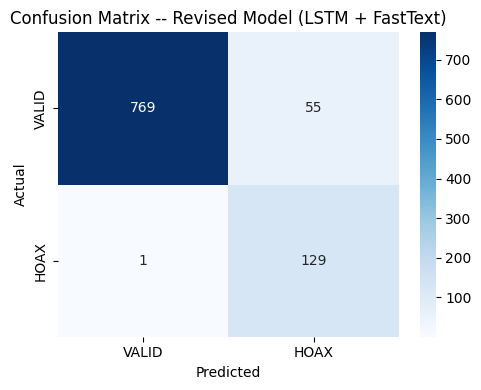

In [20]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['VALID', 'HOAX'], yticklabels=['VALID', 'HOAX'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix -- Revised Model (LSTM + FastText)')
plt.tight_layout()
plt.savefig('../docs/fig_confusion_matrix_revised.png', dpi=120)
plt.show()

## 15. Simpan hasil untuk perbandingan (notebook 03)

In [21]:
results_revised = {
    'model': 'LSTM + FastText Indonesia (PyTorch)',
    'test_accuracy': float(test_acc),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'confusion_matrix': cm.tolist(),
    'max_len': max_len,
    'vocab_size': vocab_size,
    'embedding_dim': EMBED_DIM,
    'oov_via_subword_pct': float(oov_via_subword / vocab_size * 100),
    'n_epochs_trained': len(history['train_loss']),
    'history': history,
}

os.makedirs('../docs', exist_ok=True)
with open('../docs/results_revised.json', 'w') as f:
    json.dump(results_revised, f, indent=2)

print("Hasil tersimpan ke docs/results_revised.json")
print(json.dumps({k: v for k, v in results_revised.items() if k != 'history'}, indent=2))


Hasil tersimpan ke docs/results_revised.json
{
  "model": "LSTM + FastText Indonesia (PyTorch)",
  "test_accuracy": 0.9412997903563941,
  "precision": 0.7010869565217391,
  "recall": 0.9923076923076923,
  "f1_score": 0.821656050955414,
  "confusion_matrix": [
    [
      769,
      55
    ],
    [
      1,
      129
    ]
  ],
  "max_len": 379,
  "vocab_size": 28707,
  "embedding_dim": 300,
  "oov_via_subword_pct": 39.29006862437733,
  "n_epochs_trained": 13
}


## 16. Simpan vocabulary & metadata (untuk keperluan reproduksi / analisis lanjutan)

In [ ]:
os.makedirs('../models', exist_ok=True)

with open('../models/word2idx.json', 'w') as f:
    json.dump(word2idx, f)

metadata = {
    'max_len': max_len,
    'vocab_size': vocab_size,
    'embedding_dim': EMBED_DIM,
    'pad_token': PAD_TOKEN,
    'unk_token': UNK_TOKEN,
    'label_map': {'VALID': 0, 'HOAX': 1},
}
with open('../models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Model, vocabulary, dan metadata tersimpan di folder models/")


Model, vocabulary, dan metadata tersimpan di folder models/
